[*********************100%***********************]  22 of 22 completed


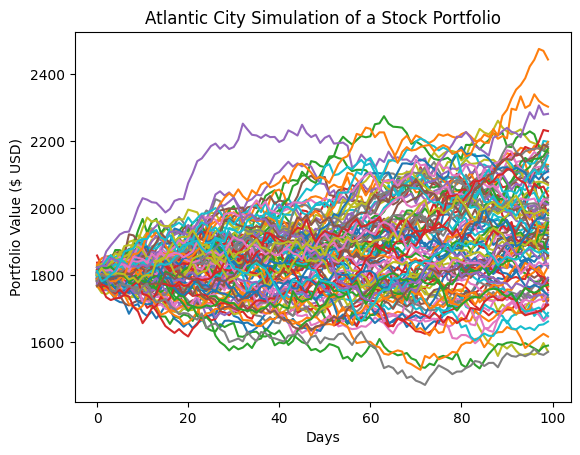

In [8]:
"""
@author: getTomsKnowledge
@date: 10/12/2024
@summary: Monte Carlo simulation of a Stock Portfolio based on \
QuantPy's video found here: https://www.youtube.com/watch?v=6-dhdMDiYWQ
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf

# import data
def get_data(stocks, start, end):
  stockData = yf.download(stocks, start, end)
  stockData = stockData["Close"]
  returns = stockData.pct_change()
  meanReturns = returns.mean()
  covMatrix = returns.cov()
  return meanReturns, covMatrix

stockList = ['ABBNY', 'BALL', 'BP', 'BKD', 'GLW', 'EW', 'F', \
            'IBM', 'IP', 'KHC', 'MBLY', 'MS', 'NOK', 'ORCL', \
            'PKE', 'PFE', 'IOT', 'SNOW', 'SPR', 'KO', 'TSN', \
             'UAL']
#stocks = [stock + '.nyse' for stock in stockList]
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=300)
meanReturns, covMatrix = get_data(stockList, startDate, endDate)

# print(meanReturns) - Sanity Check #1

weights = np.random.random(len(meanReturns))
weights /= np.sum(weights)
# print(weights) - Sanity Check #2

# Atlantic City Method
ac_sims = 100 # number of simulations
T = 100 # timeframe in days

meanM = np.full(shape=(T, len(weights)), fill_value=meanReturns)
meanM = meanM.T

portfolio_sims = np.full(shape=(T, ac_sims), fill_value=0.0)
initialPortfolio = 1800 # initial investment

for m in range(0, ac_sims):
  # AC loops:
  Z = np.random.normal(size=(T, len(weights)))
  L = np.linalg.cholesky(covMatrix)
  dailyReturns = meanM + np.inner(L,Z)
  portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1)*initialPortfolio

plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value ($ USD)')
plt.xlabel('Days')
plt.title('Atlantic City Simulation of a Stock Portfolio')
plt.show()

In [16]:
yf.download(['IBM', 'KO', 'PFE'], startDate, endDate)

[*********************100%***********************]  3 of 3 completed


Price                       Adj Close                             Close  \
Ticker                            IBM         KO        PFE         IBM   
Date                                                                      
2023-12-18 00:00:00+00:00  158.300034  57.705235  25.897280  162.740005   
2023-12-19 00:00:00+00:00  157.152222  57.519466  26.950014  161.559998   
2023-12-20 00:00:00+00:00  155.683441  56.326645  26.442787  160.050003   
2023-12-21 00:00:00+00:00  156.393509  56.698181  27.093567  160.779999   
2023-12-22 00:00:00+00:00  157.716400  57.020824  27.179701  162.139999   
...                               ...        ...        ...         ...   
2024-10-07 00:00:00+00:00  227.119995  69.010002  29.200001  227.119995   
2024-10-08 00:00:00+00:00  228.619995  69.180000  29.180000  228.619995   
2024-10-09 00:00:00+00:00  234.300003  69.570000  30.190001  234.300003   
2024-10-10 00:00:00+00:00  233.020004  69.250000  29.340000  233.020004   
2024-10-11 00:00:00+00:00  233.259995  69.570000  29.160000  233.259995   

Price                                                  High             \
Ticker                            KO        PFE         IBM         KO   
Date                                                                     
2023-12-18 00:00:00+00:00  59.020000  27.059999  163.330002  59.490002   
2023-12-19 00:00:00+00:00  58.830002  28.160000  162.279999  59.200001   
2023-12-20 00:00:00+00:00  57.610001  27.629999  161.800003  58.669998   
2023-12-21 00:00:00+00:00  57.990002  28.309999  161.080002  58.070000   
2023-12-22 00:00:00+00:00  58.320000  28.400000  162.410004  58.459999   
...                              ...        ...         ...        ...   
2024-10-07 00:00:00+00:00  69.010002  29.200001  227.669998  70.099998   
2024-10-08 00:00:00+00:00  69.180000  29.180000  229.350006  69.440002   
2024-10-09 00:00:00+00:00  69.570000  30.190001  234.949997  69.739998   
2024-10-10 00:00:00+00:00  69.250000  29.340000  235.830002  69.910004   
2024-10-11 00:00:00+00:00  69.570000  29.160000  233.440002  69.589996   

Price                                        Low                        \
Ticker                           PFE         IBM         KO        PFE   
Date                                                                     
2023-12-18 00:00:00+00:00  27.299999  161.580002  58.619999  26.719999   
2023-12-19 00:00:00+00:00  28.240000  161.320007  58.639999  27.270000   
2023-12-20 00:00:00+00:00  28.260000  160.009995  57.570000  27.610001   
2023-12-21 00:00:00+00:00  28.360001  159.529999  57.470001  27.780001   
2023-12-22 00:00:00+00:00  28.790001  161.000000  58.020000  28.180000   
...                              ...         ...        ...        ...   
2024-10-07 00:00:00+00:00  29.840000  225.020004  68.870003  29.110001   
2024-10-08 00:00:00+00:00  29.490000  227.039993  68.860001  29.000000   
2024-10-09 00:00:00+00:00  30.430000  228.500000  69.070000  29.100000   
2024-10-10 00:00:00+00:00  30.080000  231.809998  68.989998  29.280001   
2024-10-11 00:00:00+00:00  29.440001  230.460007  69.000000  28.950001   

Price                            Open                         Volume  \
Ticker                            IBM         KO        PFE      IBM   
Date                                                                   
2023-12-18 00:00:00+00:00  162.229996  58.799999  26.920000  3677300   
2023-12-19 00:00:00+00:00  161.800003  59.000000  27.280001  3766600   
2023-12-20 00:00:00+00:00  161.289993  58.500000  28.190001  4865800   
2023-12-21 00:00:00+00:00  160.589996  57.849998  27.860001  2982900   
2023-12-22 00:00:00+00:00  161.100006  58.119999  28.440001  2439800   
...                               ...        ...        ...      ...   
2024-10-07 00:00:00+00:00  225.380005  70.050003  29.370001  3458000   
2024-10-08 00:00:00+00:00  228.110001  69.040001  29.209999  3245100   
2024-10-09 00:00:00+00:00  229.199997  69.190002  29.219999  5083600   
2024-10-10 